# Quickstart

End-to-end tour: synthetic data, train/test metrics, plots, temporality (trend
and seasonality), price optimization, and model persistence.

From the repository root:

```bash
uv sync
```

MCMC settings below are small for a fast run; increase `draws` / `tune` / `chains` for production.


## 1. Generate mock data

`generate_mock_data` builds a long-format panel. We use `n_controls=1` so later steps can optimize with controls.


In [15]:
import warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

from pypricing import generate_mock_data

df = generate_mock_data(
    n_periods=6 * 52,
    n_skus=10,
    n_controls=1,
    random_state=0,
)
df.head(10)

,sku,period,price,quantity,log_price,log_quantity,control_1
0,sku_1,0,10.88,24,2.3870,3.1781,0.1530
1,sku_1,1,10.83,32,2.3823,3.4657,0.4373
2,sku_1,2,11.01,30,2.3985,3.4012,0.8744
3,sku_1,3,11.08,27,2.4049,3.2958,-0.2722
4,sku_1,4,11.20,30,2.4156,3.4012,-2.0286
5,sku_1,5,10.98,33,2.3960,3.4965,0.5726
6,sku_1,6,10.94,28,2.3921,3.3322,1.2954
7,sku_1,7,11.20,26,2.4156,3.2581,-0.4613
8,sku_1,8,11.71,26,2.4604,3.2581,0.7867
9,sku_1,9,11.28,28,2.4226,3.3322,-1.3632


### Other DGP options

- **`shape`**: `"log_log"` (default), `"quadratic"`, `"sigmoid"`.
- **`hierarchy_levels`**: e.g. `(3, 2)` adds `category_1`, `category_2`.
- **`cross_elasticity`**: `"all"` or `"within_group"` (with hierarchy).
- **`start_date` / `freq`**: calendar `period` (needed for trend / seasonality).
- **`volume_trend`**: shared annual log-growth; requires `start_date`.
- **`include_seasonality`**: yearly sine when `start_date` is set. Default `True`
  still injects a sine over integer `0 … n-1` if `start_date` is omitted — pass
  `False` unless you are fitting calendar seasonality.

See `generate_mock_data` in `synthetic_data.py` for details.


In [16]:
for shape in ("log_log", "quadratic", "sigmoid"):
    d = generate_mock_data(n_periods=8, n_skus=3, random_state=0, shape=shape)
    print(shape, "->", list(d.columns))

d_h = generate_mock_data(
    n_periods=6,
    n_skus=6,
    hierarchy_levels=(2, 3),
    random_state=1,
)
d_h[["sku", "category_1", "category_2"]].drop_duplicates()

log_log -> ['sku', 'period', 'price', 'quantity', 'log_price', 'log_quantity']
quadratic -> ['sku', 'period', 'price', 'quantity', 'log_price', 'log_quantity']
sigmoid -> ['sku', 'period', 'price', 'quantity', 'log_price', 'log_quantity']


,sku,category_1,category_2
0,sku_1,h1_0,h2_0
6,sku_2,h1_0,h2_1
12,sku_3,h1_0,h2_2
18,sku_4,h1_1,h2_3
24,sku_5,h1_1,h2_4
30,sku_6,h1_1,h2_5


## 2. Train / test split and OOS metrics

`fit_train_test` fits on the training periods, predicts the test set, and returns RMSE and HDI coverage.


In [17]:
from pypricing import LogLogDemandModel

model_oos = LogLogDemandModel()
oos = model_oos.fit_train_test(
    df,
    test_size=0.2,
    period_col="period",
    hdi_prob=0.9,
    draws=60,
    tune=60,
    chains=2,
    random_seed=0,
    progressbar=False,
    compute_convergence_checks=False,
)

print(
    "OOS metrics:",
    {k: oos[k] for k in ["rmse", "hdi_coverage", "n_train", "n_test"]},
)

Only 60 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 60 tune and 60 draw iterations (120 + 120 draws total) took 1 seconds.


OOS metrics: {'rmse': 13.473779837676672, 'hdi_coverage': 0.726984126984127, 'n_train': 2490, 'n_test': 630}


## 3. Plots: custom priors, elasticity, quantity and revenue vs price, posterior predictive check, Graphviz

Fit again with `model_config` (optional priors) and use built-in plotting helpers.


In [18]:
import pymc as pm

model_config = {
    "alpha_sku": {"dist": pm.Normal, "kwargs": {"mu": 0.0, "sigma": 2.0}},
    "elasticity_sku": {"dist": pm.Normal, "kwargs": {"mu": -1.2, "sigma": 0.5}},
    "sigma": {"dist": pm.HalfNormal, "kwargs": {"sigma": 0.5}},
}

model_cfg = LogLogDemandModel(model_config=model_config)
model_cfg.fit(
    df,
    draws=200,
    tune=200,
    chains=2,
    random_seed=0,
    progressbar=False,
    compute_convergence_checks=False,
)
model_cfg.run_diagnostics()
print("Done: model_config fit")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 6 seconds.


Done: model_config fit


<Axes: title={'center': 'Estimated own-price elasticity per SKU\n(mean + 90% HDI)'}, xlabel='Own-price elasticity'>

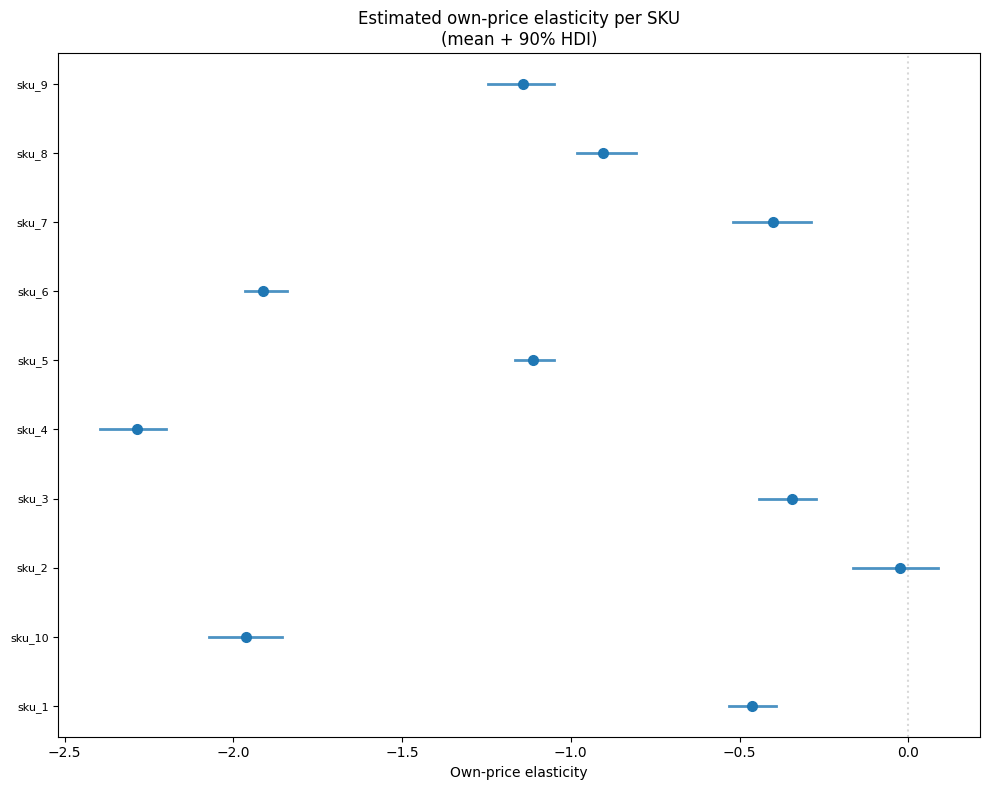

In [19]:
sku0 = model_cfg.sku_levels_[0]
model_cfg.plot_elasticity_posterior(hdi_prob=0.9)

<Axes: title={'center': 'Predicted response for sku=sku_1'}, xlabel='price', ylabel='quantity'>

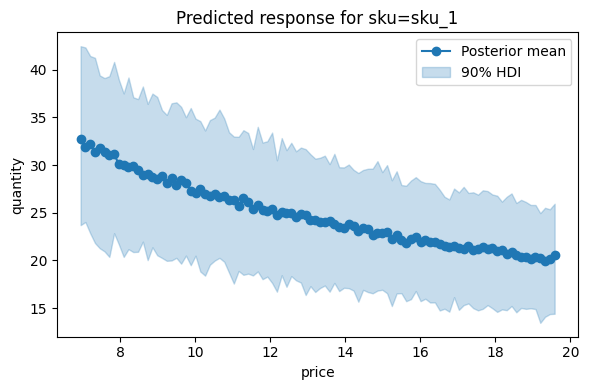

In [20]:
import numpy as np

sub0 = df[df[model_cfg.sku_col] == sku0].sort_values(model_cfg.price_col)
price_grid = np.linspace(
    float(sub0[model_cfg.price_col].min()) * 0.9,
    float(sub0[model_cfg.price_col].max()) * 1.1,
    100,
)
controls = (
    {c: float(sub0[c].iloc[0]) for c in model_cfg.control_names_}
    if model_cfg.control_names_
    else None
)

model_cfg.plot_response_curve(
    sku=sku0,
    price_grid=price_grid,
    controls=controls,
    hdi_prob=0.9,
)

### Revenue vs price

Posterior mean and predictive HDI for revenue (`price × quantity`) on the same grid and controls as the quantity response curve.


<Axes: title={'center': 'Predicted revenue for sku=sku_1'}, xlabel='price', ylabel='revenue (price × quantity)'>

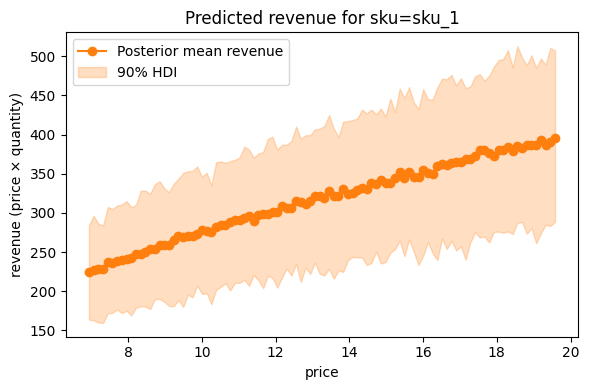

In [21]:
model_cfg.plot_revenue_vs_price(
    sku=sku0,
    price_grid=price_grid,
    controls=controls,
    hdi_prob=0.9,
    random_seed=0,
)

### Posterior predictive check (training panel)

Compare observed quantities to the predictive mean and HDI from `predict()` on the training data. Rows are ordered by `period` then `sku` when those columns exist. Use `style="calibration"` for a scatter of observed vs posterior mean with a diagonal reference line.


<Axes: title={'center': 'Calibration: observed vs predicted mean\n(90% predictive HDI available in series view)'}, xlabel='Predicted quantity (posterior mean)', ylabel='Observed quantity'>

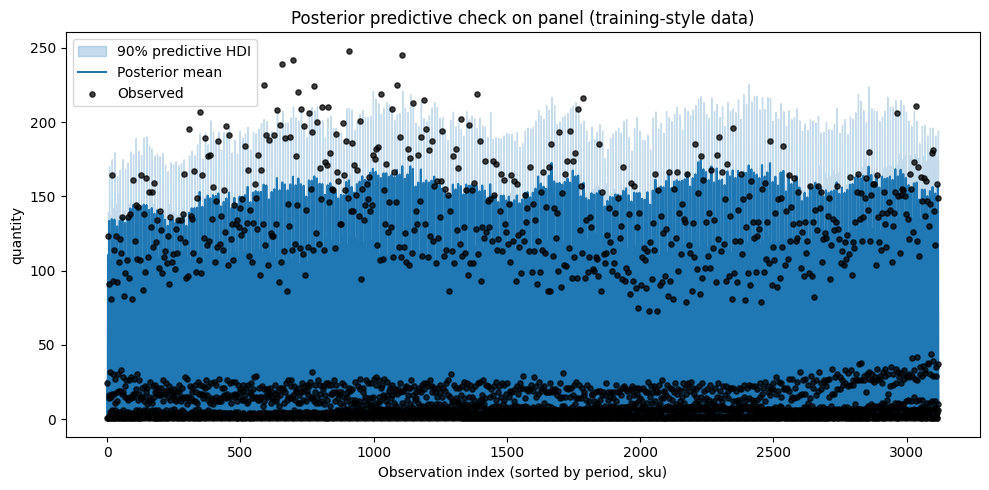

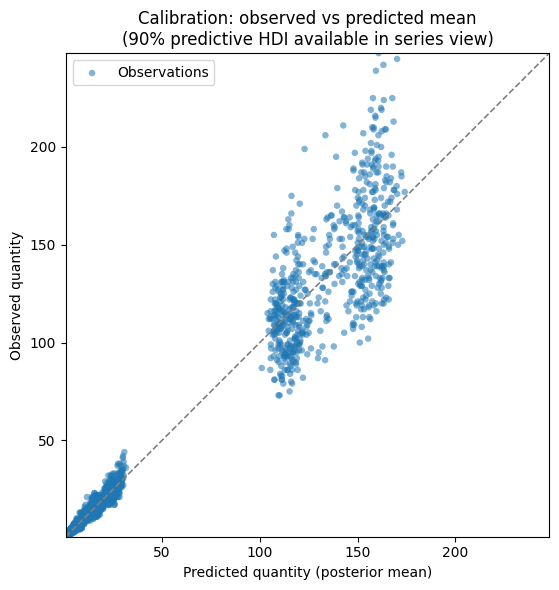

In [22]:
model_cfg.plot_posterior_predictive_calibration(
    hdi_prob=0.9, style="series", random_seed=0
)
model_cfg.plot_posterior_predictive_calibration(
    hdi_prob=0.9, style="calibration", random_seed=0
)

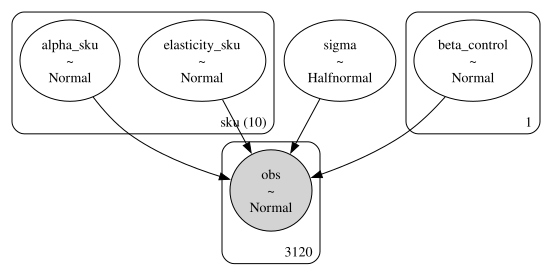

In [23]:
graph = model_cfg.graphviz()
graph

In [24]:
from pypricing.posterior import summarize_quantity_multiplier_one_sku

interpret = summarize_quantity_multiplier_one_sku(
    model_cfg,
    sku=sku0,
    price_multiplier=1.05,
    hdi_prob=0.9,
)
print("Quantity multiplier (price x1.05) for", sku0)
print("Mean:", float(interpret["quantity_multiplier_mean"]))
print("HDI:", interpret["quantity_multiplier_hdi"])

Quantity multiplier (price x1.05) for sku_1
Mean: 0.9777309901821707
HDI: (0.9743636784860074, 0.9810489617239101)


## 4. Temporality (trend and seasonality)

Integer `period` is fine until you turn these on. Then `period` must be datetime —
pass `start_date` in `generate_mock_data` so the calendar is written into `period`.

`trend="shared"` is one annual log-slope. `seasonality="auto"` picks Fourier
terms from the panel grain (weekly → yearly only). Plots and `optimize_prices`
hold the calendar at the last training date (`at_period=` to override).


In [29]:
from pypricing import LogLogDemandModel, PanelColumns, generate_mock_data

df_time = generate_mock_data(
    n_periods=2 * 52,
    n_skus=6,
    start_date="2020-01-06",
    freq="W",
    include_seasonality=True,
    volume_trend=0.08,
    round_quantity=False,
    random_state=0,
)
print("period dtype:", df_time["period"].dtype)
print("range:", df_time["period"].min(), "→", df_time["period"].max())

model_time = LogLogDemandModel(
    trend="shared",
    seasonality="auto",
    panel_columns=PanelColumns(quantity_floor=1e-12),
)
model_time.fit(
    df_time,
    draws=200,
    tune=200,
    chains=2,
    random_seed=0,
    progressbar=False,
    compute_convergence_checks=False,
)
print("auto seasonality_:", model_time.seasonality_)
model_time.fit_summary(var_names=["mu_trend", "beta_season"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, mu_trend, beta_season]
Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 3 seconds.


period dtype: datetime64[us]
range: 2020-01-12 00:00:00 → 2022-01-02 00:00:00
auto seasonality_: ('yearly',)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_trend,0.069,0.013,0.046,0.092,0.001,0.0,321.0,307.0,1.00
beta_season[0],0.146,0.007,0.132,0.157,0.000,0.0,423.0,282.0,1.01
beta_season[1],-0.005,0.007,-0.016,0.009,0.000,0.0,511.0,327.0,1.00
beta_season[2],0.000,0.007,-0.012,0.012,0.000,0.0,357.0,232.0,1.00
beta_season[3],-0.011,0.007,-0.024,0.000,0.000,0.0,539.0,243.0,1.00


## 5. Optimize prices

Fit on the **full** panel, then call `optimize_prices` with per-SKU bounds and control medians.


In [25]:
model_opt = LogLogDemandModel()
model_opt.fit(
    df,
    draws=80,
    tune=80,
    chains=2,
    random_seed=123,
    progressbar=False,
    compute_convergence_checks=False,
)

price_bounds = {
    sku: (
        float(df.loc[df["sku"] == sku, "price"].min() * 0.8),
        float(df.loc[df["sku"] == sku, "price"].max() * 1.3),
    )
    for sku in model_opt.sku_levels_
}

controls_df = df.groupby("sku", as_index=False).agg(
    control_1=("control_1", "median"),
)

opt_prices = model_opt.optimize_prices(
    price_bounds=price_bounds,
    controls_df=controls_df,
)

opt_prices.round(3)

Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 80 tune and 80 draw iterations (160 + 160 draws total) took 2 seconds.


,optimal_price,mean_revenue
sku,,
sku_1,23.140,417.094
sku_10,4.600,48.861
sku_2,25.454,25.319
sku_3,4.160,398.209
sku_4,4.080,27.720
sku_5,6.488,166.594
sku_6,3.168,58.503
sku_7,5.031,587.986
sku_8,15.509,152.469


`plot_optimization_summary` compares, for each SKU, the **reference** price (by default the average price in the training panel) to the optimizer’s `optimal_price`, and shows posterior **mean** revenue at those two price levels (using the same control rows as `optimize_prices`).

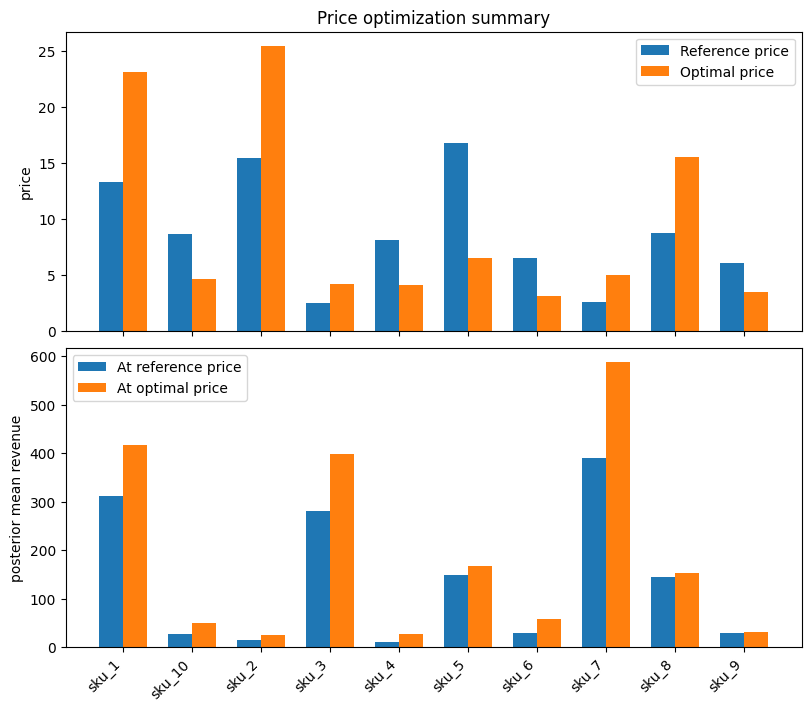

In [26]:
model_opt.plot_optimization_summary(
    opt_prices,
    controls_df=controls_df,
);

In [27]:
observed_avg_price = df.groupby("sku")["price"].mean().rename("observed_avg_price")
comparison = opt_prices.join(observed_avg_price)
comparison["price_delta_pct"] = 100 * (
    comparison["optimal_price"] / comparison["observed_avg_price"] - 1.0
)
comparison[
    ["optimal_price", "observed_avg_price", "price_delta_pct", "mean_revenue"]
].round(2)

,optimal_price,observed_avg_price,price_delta_pct,mean_revenue
sku,,,,
sku_1,23.14,13.30,73.98,417.09
sku_10,4.60,8.65,-46.85,48.86
sku_2,25.45,15.44,64.84,25.32
sku_3,4.16,2.47,68.12,398.21
sku_4,4.08,8.08,-49.52,27.72
sku_5,6.49,16.76,-61.29,166.59
sku_6,3.17,6.53,-51.50,58.50
sku_7,5.03,2.58,95.37,587.99
sku_8,15.51,8.74,77.42,152.47


## 6. Save and load

Persist the fitted optimization model with the ModelBuilder API and check that predictions match after reload.


In [28]:
import numpy as np
from pathlib import Path
from uuid import uuid4

save_path = Path("/tmp") / f"pypricing_quickstart_{uuid4().hex}.nc"
model_opt.save(save_path)
loaded = LogLogDemandModel.load(save_path)

df_pred = df.drop(columns=[model_opt.quantity_col]).copy()
pred1 = model_opt.predict(df_pred, hdi_prob=0.9, random_seed=123)
pred2 = loaded.predict(df_pred, hdi_prob=0.9, random_seed=123)

print(
    "Roundtrip identical means:",
    np.allclose(pred1["quantity_mean"], pred2["quantity_mean"]),
)

Roundtrip identical means: True
